In [1]:
import sys

from pathlib import Path
import h5py
import numpy as np

import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit

from lab_tools.io import read_keysight_h5

In [2]:
def print_info(time, voltage, metadata):
    print("frame:        ", metadata["frame"])
    print("time shape:   ", time.shape)
    print("voltage shape:", voltage.shape)
    print("X units:      ", metadata["channel_attrs"]["XUnits"]) # time units
    print("Y units:      ", metadata["channel_attrs"]["YUnits"]) # voltage units 
    print("XInc:         ", metadata["channel_attrs"]["XInc"])   # time step between samples
    print("YInc:         ", metadata["channel_attrs"]["YInc"])   # voltage step between ADC samples


In [ ]:
folder = "data"

# input voltage: negative trigger

ACQ = {"600": ["0", "08"],
       "800": ["0", "08", "1"],
       "900": [0, 1],
        }

input_voltage = "600" # 600, 800, 900

# Noise

In [ ]:
def guassian_fit_to_histV(t, v, adc_step, units_V):
    voltage = v
    # --------------------------------------------------
    # Build histogram
    # --------------------------------------------------

    # Use a bin width several ADC codes wide
    bin_width = 5 * adc_step
    bin_edges = np.arange(
        np.min(voltage),
        np.max(voltage) + bin_width,
        bin_width
    )
    counts, bin_edges = np.histogram(
        voltage,
        bins=bin_edges
    )

    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
    print(f"ADC step  = {adc_step:.3e} {units_V}")
    print(f"Bin width = {bin_width:.3e} {units_V}")
    print(f"Number of bins = {len(bin_edges)-1}")

    # --------------------------------------------------
    # Gaussian fit function
    # --------------------------------------------------

    def gaussian(x, A, mu, sigma):
        return A * np.exp(-(x - mu)**2 / (2 * sigma**2))

    # --------------------------------------------------
    # Initial values
    # --------------------------------------------------

    A0 = np.max(counts)
    mu0 = np.mean(voltage)
    sigma0 = np.std(voltage)

    p0 = [A0, mu0, sigma0]

    # --------------------------------------------------
    # Fit
    # --------------------------------------------------

    # Ignore empty bins (for stability)
    fit_mask = counts > 0

    popt, pcov = curve_fit(
        gaussian,
        bin_centers,
        counts,
        p0=p0
    )

    A_fit, mu_fit, sigma_fit = popt

    # --------------------------------------------------
    # Output
    # --------------------------------------------------

    threshold_pos = mu_fit + 5 * sigma_fit
    threshold_neg = mu_fit - 5 * sigma_fit

    print(f"Baseline mean     = {mu_fit:.3f} {units_V}")
    print(f"Baseline sigma    = {sigma_fit:.3f} {units_V}")
    print(f"+5 sigma threshold = {threshold_pos:.3f} {units_V}")
    print(f"-5 sigma threshold = {threshold_neg:.3f} {units_V}")

    # --------------------------------------------------
    # Plot
    # --------------------------------------------------

    xfit = np.linspace(bin_edges[0], bin_edges[-1], 2000)
    yfit = gaussian(xfit, *popt)

    plt.figure(figsize=(8,5))

    # Plot histogram used in fit

    plt.bar(
        bin_centers,
        counts,
        width=bin_width,
        alpha=0.6,
        align='center',
        label='Baseline histogram'

    )
    plt.plot(xfit, yfit, linewidth=1.5, label='Gaussian fit')
    
    plt.axvline(threshold_pos, linestyle='--', label='+5σ threshold')
    plt.axvline(threshold_neg, linestyle='--', label='-5σ threshold')
    plt.xlabel(f"Voltage [{units_V}]")
    plt.ylabel("Counts")
    plt.legend()
    plt.tight_layout()
    plt.show()
    


In [5]:
data_file = f"{folder}/DC_{input_voltage}V_trigauto-1.h5"
time0, voltage0, metadata0 = read_keysight_h5( data_file,
    segment_numbers=None, # if None, read segments
)
print("Data file:", data_file)
print_info(time0, voltage0, metadata0)

data_file = f"{folder}/DC_{input_voltage}V_trigauto-2.h5"
time1, voltage1, metadata1 = read_keysight_h5( data_file, segment_numbers=None)
print("\nData file:", data_file)
print_info(time1, voltage1, metadata1)

Data file: data/DC_600V_trigauto-1.h5
frame:         {'Model': 'EXR054A', 'Serial': 'MY63310243', 'Date': '18-May-2026 10:18:57'}
time shape:    (134217728,)
voltage shape: (1, 134217728)
X units:       Second
Y units:       Volt
XInc:          6.25e-11
YInc:          2.5510204081632653e-06

Data file: data/DC_600V_trigauto-2.h5
frame:         {'Model': 'EXR054A', 'Serial': 'MY63310243', 'Date': '18-May-2026 10:19:34'}
time shape:    (134217728,)
voltage shape: (1, 134217728)
X units:       Second
Y units:       Volt
XInc:          6.25e-11
YInc:          2.5510204081632653e-06


In [6]:
# units
voltage0_mV = voltage0[0] * 1e3
adc_step0_mV = metadata0["channel_attrs"]["YInc"] * 1e3  
time0_us = time0 * 1e6

voltage1_mV = voltage1[0] * 1e3
adc_step1_mV = metadata1["channel_attrs"]["YInc"] * 1e3  
time1_us = time1 * 1e6

units_V = "mV"
units_time = "µs"


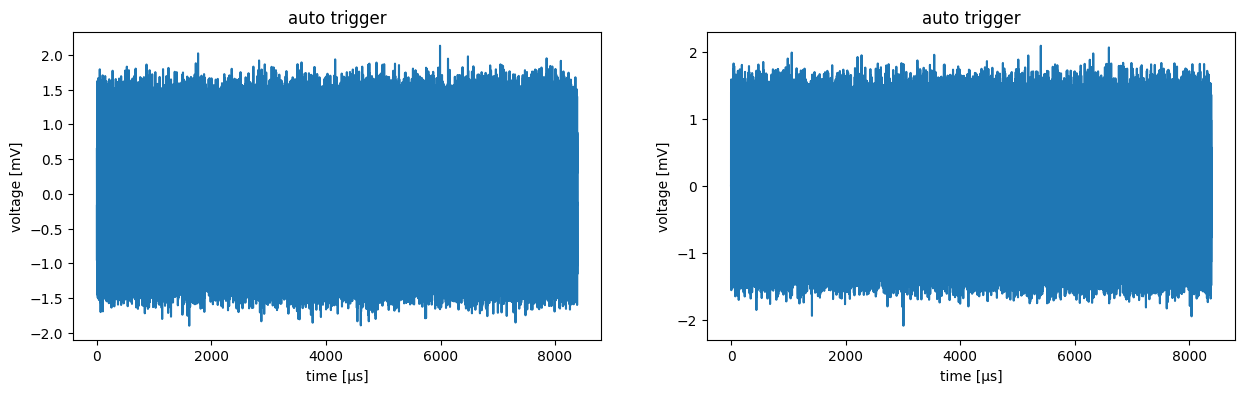

In [7]:
fig, axs = plt.subplots(1, 2, figsize=(15, 4))
axs[0].plot(time0_us, voltage0_mV)
axs[0].set_xlabel(f"time [{units_time}]")
axs[0].set_ylabel(f"voltage [{units_V}]")
axs[0].set_title("auto trigger")

axs[1].plot(time1_us, voltage1_mV)
axs[1].set_xlabel(f"time [{units_time}]")
axs[1].set_ylabel(f"voltage [{units_V}]")
axs[1].set_title("auto trigger")

plt.show();

ADC step  = 2.551e-03 mV
Bin width = 1.276e-02 mV
Number of bins = 316
Baseline mean     = -0.068 mV
Baseline sigma    = 0.155 mV
+5 sigma threshold = 0.707 mV
-5 sigma threshold = -0.843 mV


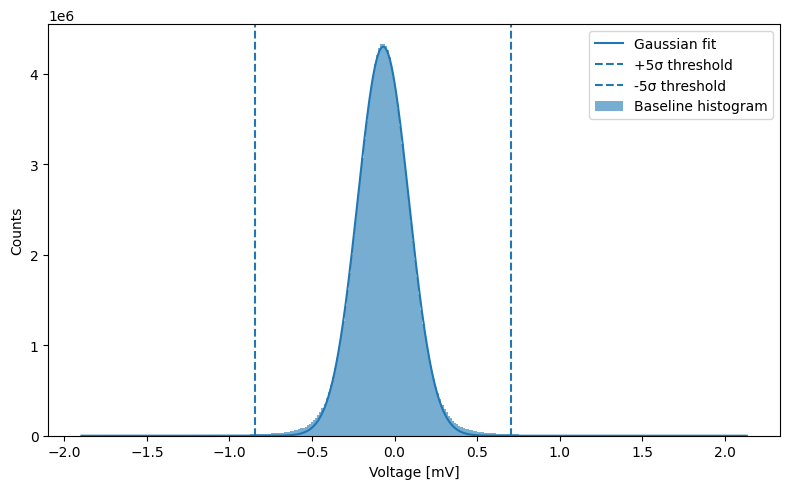

In [ ]:
guassian_fit_to_histV(t=time0_us, v=voltage0_mV, adc_step=adc_step0_mV, units_V=units_V)

ADC step  = 2.551e-03 mV
Bin width = 1.276e-02 mV
Number of bins = 328
Baseline mean     = -0.083 mV
Baseline sigma    = 0.157 mV
+5 sigma threshold = 0.700 mV
-5 sigma threshold = -0.866 mV


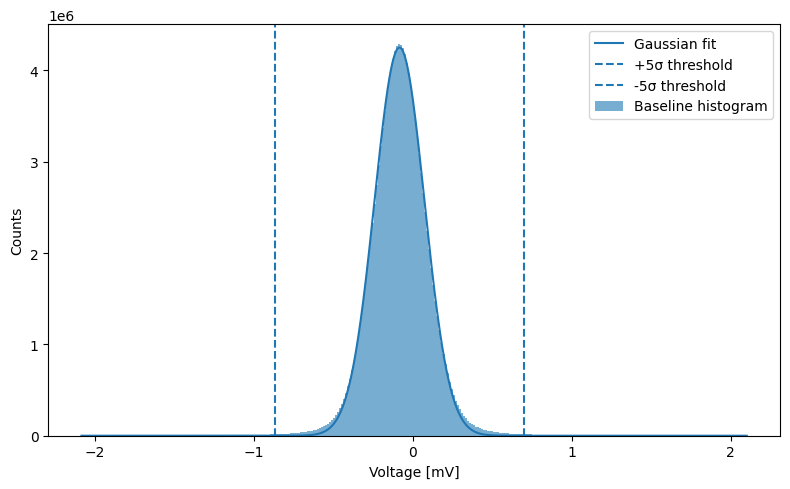

In [ ]:
guassian_fit_to_histV(t=time1_us, v=voltage1_mV, adc_step=adc_step1_mV)

# Dark Counts

In [11]:
# data_files_seq = [
#     f"{folder}/DC_600V_trig0mV.h5", # 0
#     f"{folder}/DC_600V_trig08mV.h5", # 1
#     f"{folder}/DC_800V_trig0V.h5", # 2
#     f"{folder}/DC_800V_trig1mV.h5", # 3
#     f"{folder}/DC_800V_trig1mV-2.h5", # 4
#     f"{folder}/DC_800V_trig08mV.h5", # 5
#     ]

In [12]:
# data_file = data_files_seq[4] 
# time_test, voltage_test, metadata_test = read_keysight_h5( data_file, segment_numbers=None)
# print("\nData file:", data_file)
# print_info(time_test, voltage_test, metadata_test)

# data_file = data_files_seq[5] 
# time, voltage, metadata = read_keysight_h5( data_file, segment_numbers=None)
# print("\nData file:", data_file)
# print_info(time, voltage, metadata)

In [13]:
# np.mean(voltage_test[:, 0])
# np.mean(voltage[:, 0])

In [14]:
# Nseg = 1000
# fig, axs = plt.subplots(1, 2, figsize=(15, 4))
# for i in range(0, Nseg):
#     axs[0].plot(time_test * 1e9, voltage_test[i] * 1e3)
# axs[0].set_xlabel("time [ns]")
# axs[0].set_ylabel("voltage [mV]")
# # axs[0].set_title("Trigger threshold = 0 mV")

# for i in range(0, Nseg):
#     axs[1].plot(time * 1e9, voltage[i] * 1e3)
# axs[1].set_xlabel("time [ns]")
# axs[1].set_ylabel("voltage [mV]")
# # axs[1].set_title("Trigger threshold = 1 mV")

# plt.show();


In [15]:
# Nseg = 10
# fig, axs = plt.subplots(1, 2, figsize=(15, 4))
# for i in range(0, Nseg):
#     axs[0].plot(time0 * 1e9, voltage0[i] * 1e3)
# axs[0].set_xlabel("time [ns]")
# axs[0].set_ylabel("voltage [mV]")
# axs[0].set_title("Trigger threshold = 0 mV")

# for i in range(0, Nseg):
#     axs[1].plot(time1 * 1e9, voltage1[i] * 1e3)
# axs[1].set_xlabel("time [ns]")
# axs[1].set_ylabel("voltage [mV]")
# axs[1].set_title("Trigger threshold = 1 mV")

# plt.show();

# # plt.axhline(y=threshold, color="red", linestyle="--", label=f"threshold = {threshold*1e3} mV");
# # plt.axhline(y=-threshold, color="red", linestyle="--", label=f"threshold = {threshold*1e3} mV");

In [16]:
# fig, axs = plt.subplots(1, 2, figsize=(15, 4))
# axs[0].plot(time0 * 1e9, np.mean(voltage0, axis=0) * 1e3)
# axs[0].set_xlabel("time [ns]")
# axs[0].set_ylabel("voltage [mV]")
# axs[0].set_title("Mean waveform, Trigger = 0 mV")

# axs[1].plot(time1 * 1e9, np.mean(voltage1, axis=0) * 1e3)
# axs[1].set_xlabel("time [ns]")
# axs[1].set_ylabel("voltage [mV]")
# axs[1].set_title("Mean waveform, Trigger = 1 mV")

# plt.show();


In [17]:

# fig, axs = plt.subplots(1, 2, figsize=(15, 4))
# axs[0].hist(np.sum(voltage0, axis=1), bins=100);
# axs[0].set_title("Total charge, Trigger = 0 mV")
# axs[0].set_xlabel("Charge [V*s]")
# axs[1].hist(np.sum(voltage1, axis=1), bins=100);
# axs[1].set_title("Total charge, Trigger = 1 mV")
# axs[1].set_xlabel("Charge [V*s]")

# plt.show();
